# Social Media Usage Analysis (Week 23.03 - 29.03.2026)


This notebook analyzes social media usage across PC (ActivityWatch) and iPhone (Screen Time) data.

Data sources:
- `aw-events-export-aw-watcher-window_DESKTOP-GVUBFOR-2026-04-01.csv`: Window events (PC apps)
- `aw-events-export-aw-watcher-web-firefox_DESKTOP-GVUBFOR-2026-04-01.csv`: Firefox web browsing (PC)
- `iphone.csv`: iPhone screen time (exported)

Social media platforms considered:
- WhatsApp (PC app + iPhone)
- Discord (PC app + web)
- Spotify (PC app + iPhone)
- YouTube (web)
- LinkedIn (web)
- Reddit (web)
- Instagram (web)

Platforms with less than 1% of total usage are filtered out.


In [4]:
import pandas as pd
import numpy as np
import re
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import warnings
warnings.filterwarnings('ignore')

# Set inline plotting
%matplotlib inline

In [5]:
#DATA_DIR = "C:/Users/Admin/Documents/social_media"
WINDOW_CSV = os.path.join("aw-events-export-aw-watcher-window_DESKTOP-GVUBFOR-2026-04-01.csv")
WEB_CSV = os.path.join("aw-events-export-aw-watcher-web-firefox_DESKTOP-GVUBFOR-2026-04-01.csv")
IPHONE_CSV = os.path.join("iphone.csv")

START_DATE = datetime(2026, 3, 23, tzinfo=timezone.utc)
END_DATE = datetime(2026, 3, 30, tzinfo=timezone.utc)  # exclusive

SOCIAL_MEDIA_APPS = {
    "WhatsApp": ["WhatsApp.Root.exe"],
    "Discord": ["Discord.exe"],
    "Spotify": ["Spotify.exe"],
}

SOCIAL_MEDIA_DOMAINS = {
    "YouTube": ["youtube.com", "youtu.be"],
    "Instagram": ["instagram.com"],
    "LinkedIn": ["linkedin.com"],
    "Reddit": ["reddit.com"],
    "Discord": ["discord.com"],
}

def parse_duration_seconds(duration_str):
    if isinstance(duration_str, (int, float)):
        return float(duration_str)
    if 'min' in duration_str:
        minutes = float(duration_str.replace('min', '').strip())
        return minutes * 60
    elif 's' in duration_str:
        seconds = float(duration_str.replace('s', '').strip())
        return seconds
    else:
        try:
            return float(duration_str)
        except:
            return 0.0

def load_window_data():
    df = pd.read_csv(WINDOW_CSV)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    mask = (df['timestamp'] >= START_DATE) & (df['timestamp'] < END_DATE)
    df = df[mask].copy()
    df['date'] = df['timestamp'].dt.date
    df['platform'] = None
    for platform, app_names in SOCIAL_MEDIA_APPS.items():
        for app in app_names:
            df.loc[df['app'] == app, 'platform'] = platform
    df_social = df[df['platform'].notna()].copy()
    df_social['source'] = 'PC'
    return df_social

def load_web_data():
    df = pd.read_csv(WEB_CSV)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    mask = (df['timestamp'] >= START_DATE) & (df['timestamp'] < END_DATE)
    df = df[mask].copy()
    df['date'] = df['timestamp'].dt.date
    df['platform'] = None
    for platform, domains in SOCIAL_MEDIA_DOMAINS.items():
        for domain in domains:
            df.loc[df['url'].str.contains(domain, case=False, na=False), 'platform'] = platform
    df_social = df[df['platform'].notna()].copy()
    df_social['source'] = 'PC'
    return df_social

def load_iphone_data():
    df = pd.read_csv(IPHONE_CSV, delimiter=',')
    def parse_date(datum):
        match = re.search(r'(\d{2})\.(\d{2})', datum)
        if match:
            day = int(match.group(1))
            month = int(match.group(2))
            return datetime(2026, month, day).date()
        else:
            return None
    df['date'] = df['Datum'].apply(parse_date)
    mask = (df['date'] >= START_DATE.date()) & (df['date'] < END_DATE.date())
    df = df[mask].copy()
    df['platform'] = None
    social_apps = ['WhatsApp', 'Spotify']
    for app in social_apps:
        df.loc[df['App/Website'] == app, 'platform'] = app
    df_social = df[df['platform'].notna()].copy()
    df_social['duration_seconds'] = df_social['Nutzungsdauer'].apply(parse_duration_seconds)
    df_social['source'] = 'iPhone'
    return df_social

def combine_daily(df_window, df_web, df_iphone):
    # Combine durations per platform per date
    window_daily = df_window.groupby(['date', 'platform'])['duration'].sum().reset_index()
    web_daily = df_web.groupby(['date', 'platform'])['duration'].sum().reset_index()
    iphone_daily = df_iphone.groupby(['date', 'platform'])['duration_seconds'].sum().reset_index()
    iphone_daily = iphone_daily.rename(columns={'duration_seconds': 'duration'})
    combined = pd.concat([window_daily, web_daily, iphone_daily], ignore_index=True)
    # Sum across same platform on same day
    combined = combined.groupby(['date', 'platform'])['duration'].sum().reset_index()
    combined['minutes'] = combined['duration'] / 60.0
    return combined

In [6]:
print("Loading data...")
df_window = load_window_data()
df_web = load_web_data()
df_iphone = load_iphone_data()
print("Window events:", len(df_window))
print("Web events:", len(df_web))
print("iPhone events:", len(df_iphone))

# Combine daily totals (ignoring source)
daily = combine_daily(df_window, df_web, df_iphone)
print("\nDaily combined entries:", len(daily))
print(daily.head())

# Combine daily with source information
window_daily = df_window.groupby(['date', 'platform', 'source'])['duration'].sum().reset_index()
web_daily = df_web.groupby(['date', 'platform', 'source'])['duration'].sum().reset_index()
iphone_daily = df_iphone.groupby(['date', 'platform', 'source'])['duration_seconds'].sum().reset_index()
iphone_daily = iphone_daily.rename(columns={'duration_seconds': 'duration'})
daily_source = pd.concat([window_daily, web_daily, iphone_daily], ignore_index=True)
daily_source['minutes'] = daily_source['duration'] / 60.0
print("\nDaily entries with source:", len(daily_source))
print(daily_source.head())

Loading data...
Window events: 473
Web events: 109
iPhone events: 13

Daily combined entries: 26
         date  platform  duration    minutes
0  2026-03-23  WhatsApp  2535.026  42.250433
1  2026-03-24   Spotify    10.000   0.166667
2  2026-03-24  WhatsApp  1654.275  27.571250
3  2026-03-25   Discord  1443.850  24.064167
4  2026-03-25   Spotify   344.039   5.733983

Daily entries with source: 36
         date  platform source  duration    minutes
0  2026-03-23  WhatsApp     PC  1215.026  20.250433
1  2026-03-24  WhatsApp     PC   754.275  12.571250
2  2026-03-25   Discord     PC  1443.850  24.064167
3  2026-03-25   Spotify     PC   224.039   3.733983
4  2026-03-25  WhatsApp     PC  2149.244  35.820733


## Daily Usage per Platform

Bar charts showing minutes per platform for each day.

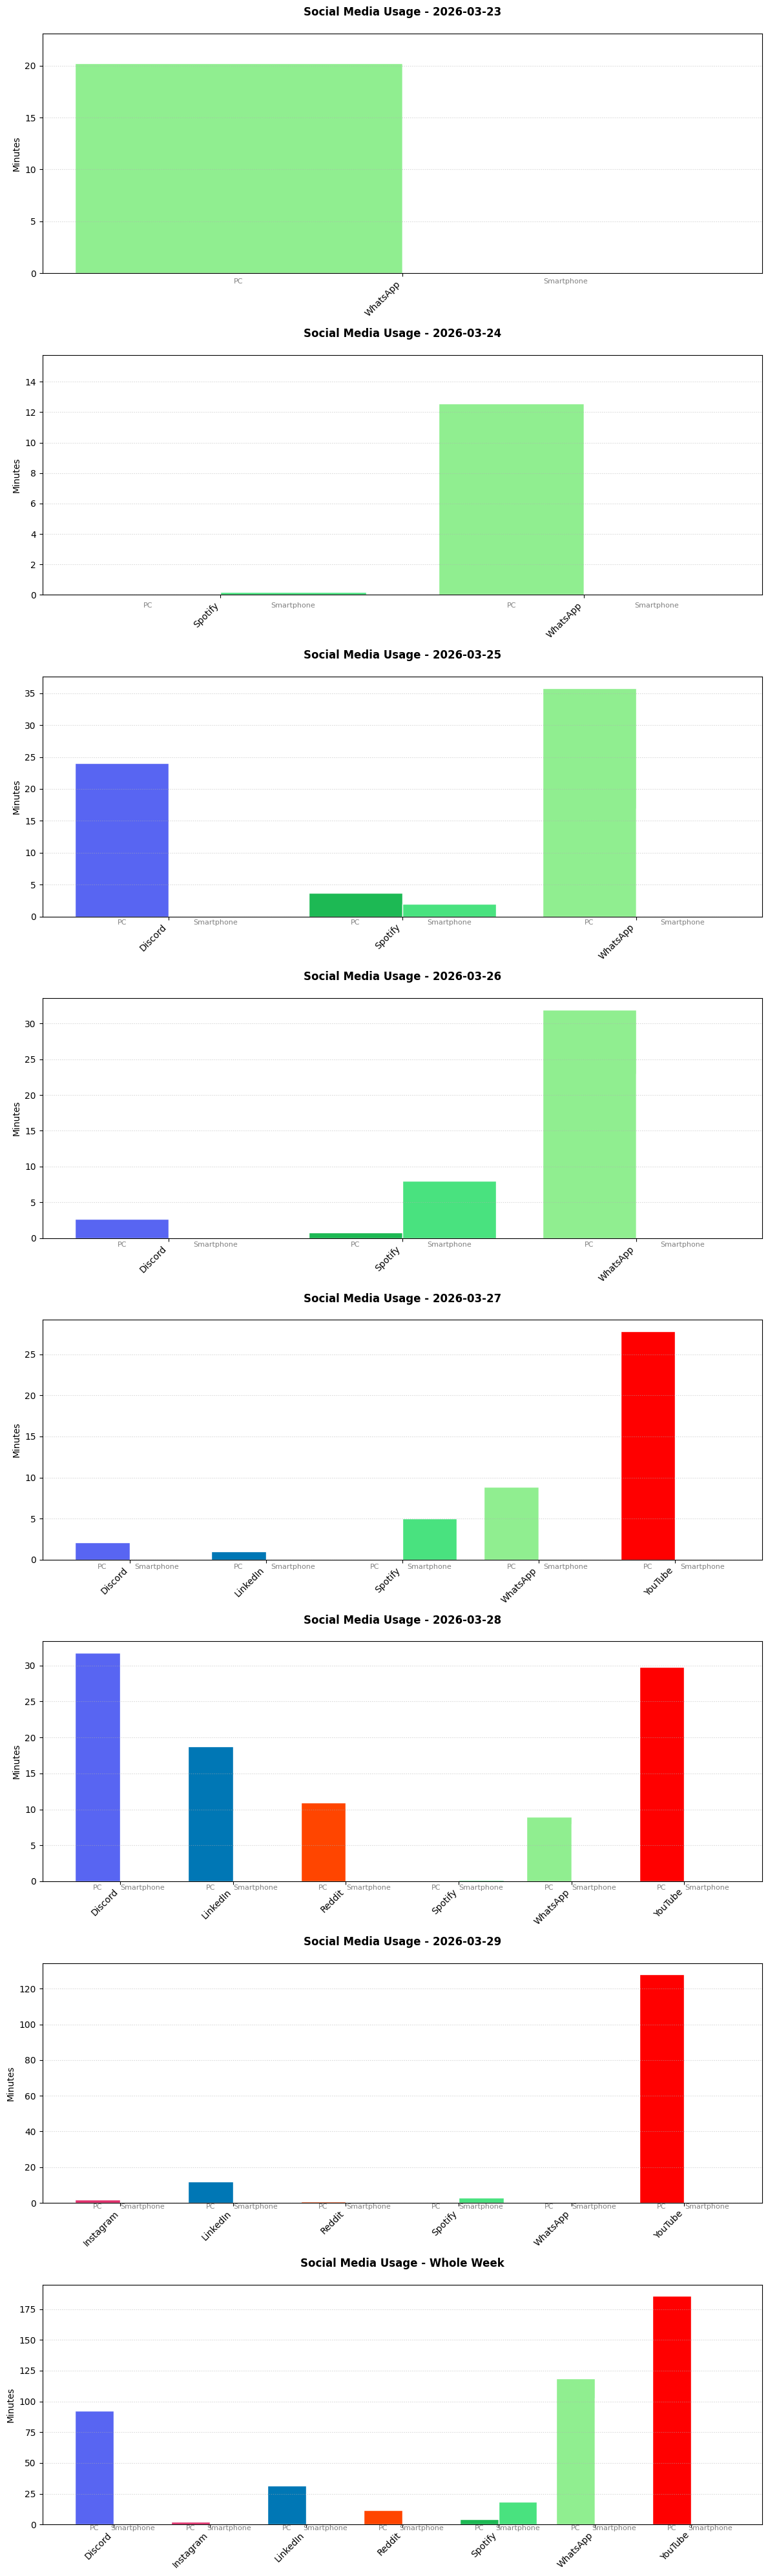

In [7]:
import matplotlib.colors as mcolors

# 1. Definiere deine Grundfarben
BASE_COLORS = {
    "WhatsApp": "#90EE90",   # Hellgrün
    "Spotify": "#1DB954",    # Spotify-Grün
    "Reddit": "#FF4500",     # Orange
    "YouTube": "#FF0000",    # Rot
    "Discord": "#5865F2",    # Stärkeres, offizielles Discord-Lila
    "Instagram": "#E1306C",  # Pink
    "LinkedIn": "#0077B5"    # LinkedIn-Blau
}

def get_color(platform, source):
    base_hex = BASE_COLORS.get(platform, "#808080") # Grau falls Plattform unbekannt
    rgb = mcolors.to_rgb(base_hex)
    
    # Handy etwas dunkler oder heller? 
    # Hier: PC = Original, iPhone = 30% heller
    if source == 'iPhone':
        return mcolors.lighten_rgb(rgb, 0.3) 
    return rgb

# Hilfsfunktion zum Aufhellen (da Matplotlib das nicht nativ im Dictionary hat)
def adjust_lightness(color, amount=0.5):
    import colorsys
    try:
        c = mcolors.to_rgb(color)
        c = colorsys.rgb_to_hls(*c)
        return colorsys.hls_to_rgb(c[0], max(0, min(1, c[1] * amount)), c[2])
    except:
        return color

# --- PLOTTING ---

days = sorted(daily['date'].unique())
n_days = len(days)
fig, axes = plt.subplots(n_days + 1, 1, figsize=(12, 5 * (n_days + 1)))
axes = np.atleast_1d(axes).flatten()

def plot_custom_bars(ax, data, title):
    # Pivot: Plattformen sind Zeilen, PC/iPhone sind Spalten
    pivot = data.pivot_table(index='platform', columns='source', values='minutes', fill_value=0)
    
    platforms = pivot.index
    sources = pivot.columns
    x = np.arange(len(platforms))
    width = 0.4  # Etwas breiter für bessere Lesbarkeit
    
    for i, source in enumerate(sources):
        colors = []
        for p in platforms:
            base = BASE_COLORS.get(p, "#808080")
            # iPhone (heller), PC (original)
            col = adjust_lightness(base, 1.4 if source == 'iPhone' else 1.0)
            colors.append(col)
        
        # Plotten der Balken
        bars = ax.bar(x + i*width, pivot[source], width, color=colors, edgecolor='white', linewidth=1)
        
        # Kennzeichnung direkt an den Balken (PC / iPh)
        # Wir setzen ein kleines Label unter jeden Balken
        label_text = "Smartphone" if source == 'iPhone' else "PC"
        for bar in bars:
            height = bar.get_height()
            # Wir schreiben das Label knapp über 0 oder unter den Balken
            ax.text(bar.get_x() + bar.get_width()/2., -0.5, label_text, 
                    ha='center', va='top', fontsize=8, color='gray')

    ax.set_title(title, pad=20, fontweight='bold')
    ax.set_ylabel('Minutes')
    
    # X-Achse anpassen: Plattformnamen stehen mittig unter den Balken-Paaren
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(platforms, rotation=45, ha='right', fontsize=10)
    
    # Legende entfernen
    if ax.get_legend():
        ax.get_legend().remove()
    
    # Etwas Platz nach unten für die PC/iPh Beschriftung lassen
    ax.set_ylim(bottom=0) 
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Daily Plots
for i, day in enumerate(days):
    day_data = daily_source[daily_source['date'] == day]
    plot_custom_bars(axes[i], day_data, f'Social Media Usage - {day}')

# Weekly Plot
weekly_data = daily_source.groupby(['platform', 'source'])['minutes'].sum().reset_index()
plot_custom_bars(axes[-1], weekly_data, 'Social Media Usage - Whole Week')

plt.tight_layout()
plt.show()

## Daily Distribution (Pie Charts)

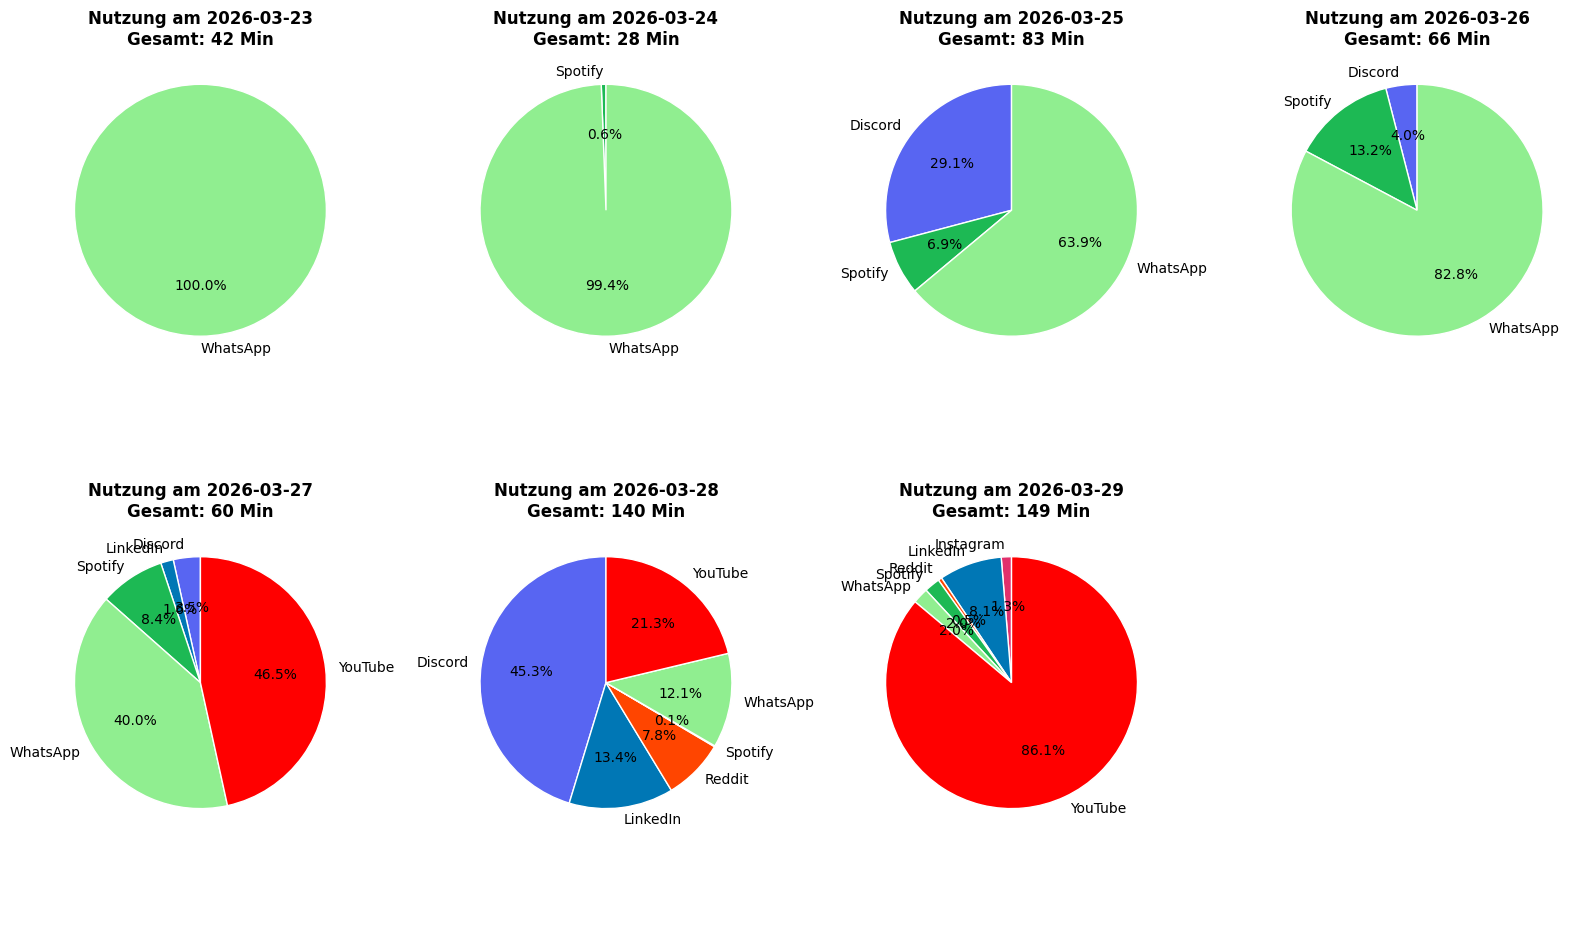

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, day in enumerate(days):
    if i >= len(axes):
        break
        
    day_data = daily[daily['date'] == day]
    # Nur Plattformen mit mehr als 0 Minuten anzeigen
    day_data = day_data[day_data['minutes'] > 0].copy()
    
    # --- NEU: Gesamtminuten berechnen ---
    total_minutes = day_data['minutes'].sum()
    
    if day_data.empty:
        axes[i].text(0.5, 0.5, "Keine Daten", ha='center')
        axes[i].set_title(f'{day}')
        axes[i].axis('off')
        continue

    # Erstelle die Farbliste basierend auf den vorhandenen Plattformen
    pie_colors = [BASE_COLORS.get(p, "#808080") for p in day_data['platform']]

    ax = axes[i]
    day_data.set_index('platform')['minutes'].plot(
        kind='pie', 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    
    # --- TITEL AKTUALISIERT: Datum und Gesamtminuten anzeigen ---
    ax.set_title(f'Nutzung am {day}\nGesamt: {total_minutes:.0f} Min', fontweight='bold')
    ax.set_ylabel('')

# Unbenutzte Subplots ausblenden
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Weekly Aggregate

In [9]:
# Gruppieren nach Plattform und Quelle
weekly_source = daily_source.groupby(['platform', 'source'])['minutes'].sum().unstack(fill_value=0)

# Gesamtzeit berechnen und sortieren
weekly_source['total'] = weekly_source.sum(axis=1)
weekly_source = weekly_source.sort_values('total', ascending=False)

# 1% Filter anwenden
total_usage = weekly_source['total'].sum()
threshold = total_usage * 0.01
weekly_filtered = weekly_source[weekly_source['total'] >= threshold].copy()

# Tabellenausgabe
print(f"--- Wochenstatistik (Gesamt: {total_usage:.1f} Min) ---")
print(weekly_filtered[['PC', 'iPhone', 'total']].round(2))

--- Wochenstatistik (Gesamt: 567.7 Min) ---
source        PC  iPhone   total
platform                        
WhatsApp  118.47   103.0  221.47
YouTube   185.64     0.0  185.64
Discord    92.33     0.0   92.33
LinkedIn   31.78     0.0   31.78
Spotify     4.53    18.3   22.83
Reddit     11.69     0.0   11.69


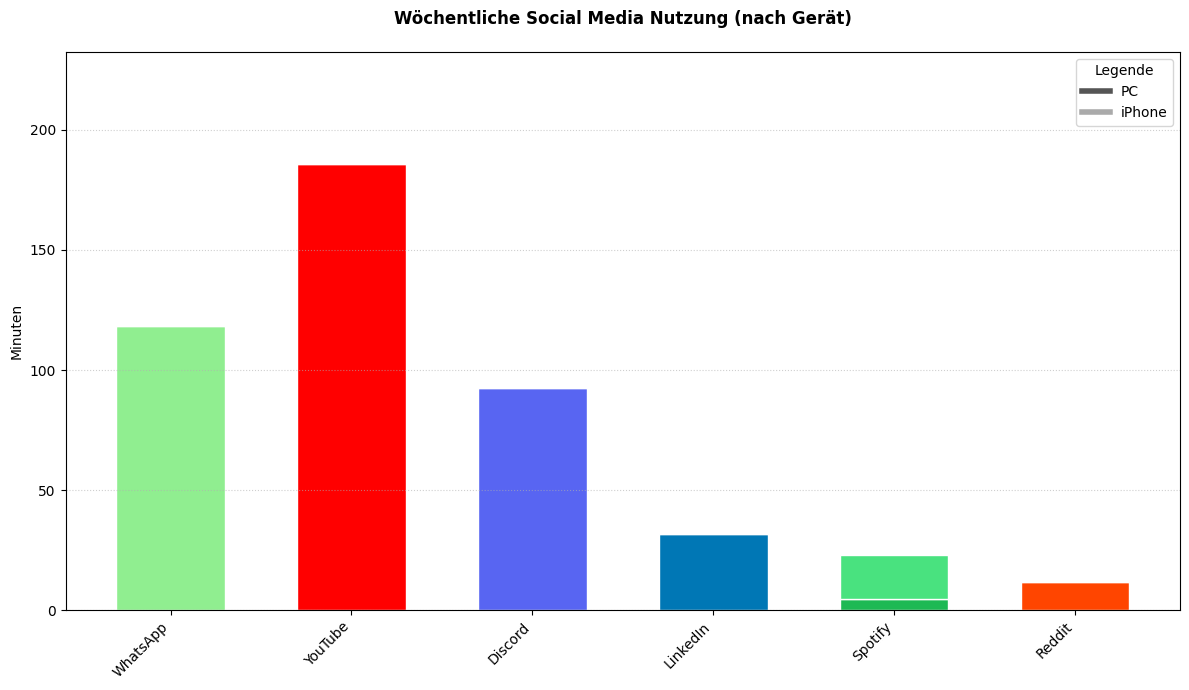

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Vorbereitung der Plot-Variablen
platforms = weekly_filtered.index
x = np.arange(len(platforms))
width = 0.6
fig, ax = plt.subplots(figsize=(12, 7))

# Balken für jede Quelle stapeln
bottoms = np.zeros(len(platforms))
sources = ['PC', 'iPhone']

for source in sources:
    if source in weekly_filtered.columns:
        durations = weekly_filtered[source]
        
        # Farben basierend auf der Plattform und Helligkeit zuweisen
        bar_colors = []
        for p in platforms:
            base = BASE_COLORS.get(p, "#808080")
            # PC = Original, iPhone = Heller (Faktor 1.4)
            col = adjust_lightness(base, 1.4 if source == 'iPhone' else 1.0)
            bar_colors.append(col)
        
        ax.bar(x, durations, bottom=bottoms, label=source, color=bar_colors, edgecolor='white', width=width)
        bottoms += durations

# Styling
ax.set_title('Wöchentliche Social Media Nutzung (nach Gerät)', fontweight='bold', pad=20)
ax.set_ylabel('Minuten')
ax.set_xticks(x)
ax.set_xticklabels(platforms, rotation=45, ha='right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Manuelle Legende für die Geräte-Unterscheidung
legend_elements = [
    Line2D([0], [0], color='#555555', lw=4, label='PC'),
    Line2D([0], [0], color='#AAAAAA', lw=4, label='iPhone')
]
ax.legend(handles=legend_elements, loc='upper right', title="Legende")

plt.tight_layout()
plt.show()

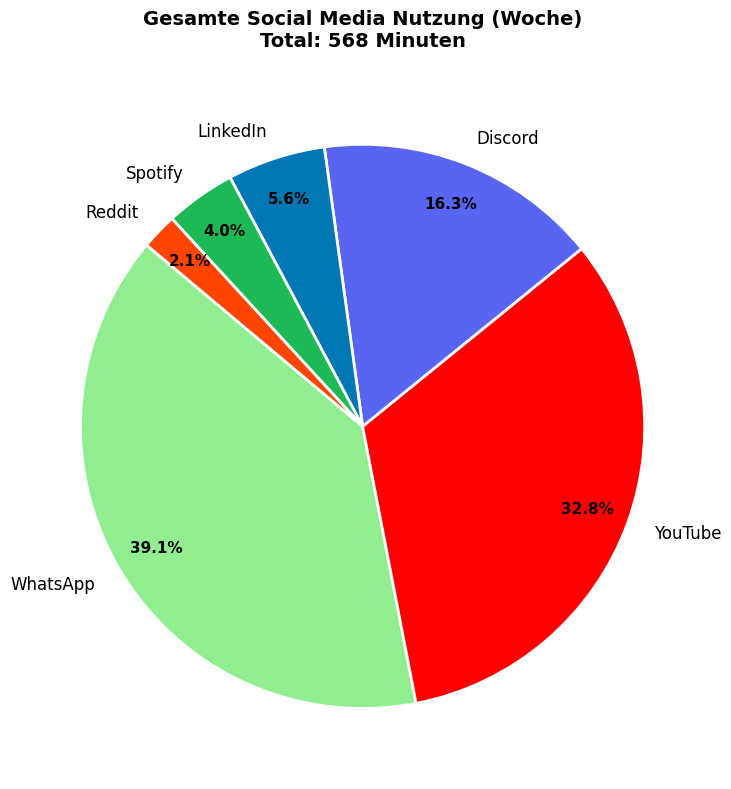

In [11]:
# 1. Daten aggregieren: Summe über die ganze Woche pro Plattform
weekly_total = daily.groupby('platform')['minutes'].sum().sort_values(ascending=False)

# Filter für Kleinstmengen (unter 1%), damit das Diagramm sauber bleibt
total_sum = weekly_total.sum()
weekly_pie_data = weekly_total[weekly_total >= (total_sum * 0.01)]

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 8))

# Farbliste generieren (konsistent zu deinen anderen Plots)
pie_colors = [BASE_COLORS.get(p, "#808080") for p in weekly_pie_data.index]

wedges, texts, autotexts = ax.pie(
    weekly_pie_data, 
    labels=weekly_pie_data.index,
    autopct='%1.1f%%', 
    startangle=140,
    colors=pie_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'color': 'black'}, # Plattformnamen in Schwarz
    pctdistance=0.85 # Prozentzahlen etwas weiter nach außen, falls die Farben zu dunkel sind
)

# Styling der Prozentangaben explizit auf Schwarz setzen
plt.setp(autotexts, size=11, weight="bold", color="black")

ax.set_title(f'Gesamte Social Media Nutzung (Woche)\nTotal: {total_sum:.0f} Minuten', 
             fontweight='bold', 
             fontsize=14, 
             pad=20,
             color='black')

plt.tight_layout()
plt.show()

## Summary Table

In [12]:
summary = daily.pivot_table(index='date', columns='platform', values='minutes', aggfunc='sum', fill_value=0)
print("Daily minutes per platform:")
print(summary.round(2))
print("\nWeekly totals:")
print(summary.sum().round(2))

Daily minutes per platform:
platform    Discord  Instagram  LinkedIn  Reddit  Spotify  WhatsApp  YouTube
date                                                                        
2026-03-23     0.00       0.00      0.00    0.00     0.00     42.25     0.00
2026-03-24     0.00       0.00      0.00    0.00     0.17     27.57     0.00
2026-03-25    24.06       0.00      0.00    0.00     5.73     52.82     0.00
2026-03-26     2.65       0.00      0.00    0.00     8.78     54.94     0.00
2026-03-27     2.07       0.00      0.97    0.00     5.00     23.88    27.80
2026-03-28    63.54       0.00     18.80   10.99     0.15     17.01    29.82
2026-03-29     0.00       1.95     12.01    0.70     3.00      3.00   128.02

Weekly totals:
platform
Discord       92.33
Instagram      1.95
LinkedIn      31.78
Reddit        11.69
Spotify       22.83
WhatsApp     221.47
YouTube      185.64
dtype: float64


## Export Results

In [13]:
# Save daily summary to CSV
daily.to_csv('social_media_daily_summary.csv', index=False)
weekly_filtered.to_csv('social_media_weekly_filtered.csv', header=True)
print("CSV files saved.")

CSV files saved.



## Interpretation

- **WhatsApp** dominates usage across PC and iPhone.
- **YouTube** is second largest (likely video consumption).
- **Discord** used for communication.
- **LinkedIn** and **Reddit** have moderate usage.
- **Instagram** usage was minimal (<1% of total) and filtered out.

Recommendations: Consider reducing time on YouTube if excessive, or set limits.


In [14]:
# This cell is just for demonstration; you can ignore.
print('Notebook execution completed.')

Notebook execution completed.
